In [ ]:
!pip -q install pyarrow pandas numpy scikit-learn xgboost joblib matplotlib


In [ ]:
import os
import pandas as pd
import numpy as np
from pathlib import Path

DATASET_DIR = Path("/kaggle/input/cicids2017")

parquets = sorted(DATASET_DIR.glob("*.parquet"))
print("Parquet files:", len(parquets))
for p in parquets:
    print(" -", p.name)

dfs = []
for p in parquets:
    df = pd.read_parquet(p)  # pyarrow backend
    df["source_file"] = p.name  # helpful for debugging/analysis
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)
print("Loaded shape:", data.shape)
print("Columns (first 30):", data.columns[:30].tolist())


Parquet files: 8
 - Benign-Monday-no-metadata.parquet
 - Botnet-Friday-no-metadata.parquet
 - Bruteforce-Tuesday-no-metadata.parquet
 - DDoS-Friday-no-metadata.parquet
 - DoS-Wednesday-no-metadata.parquet
 - Infiltration-Thursday-no-metadata.parquet
 - Portscan-Friday-no-metadata.parquet
 - WebAttacks-Thursday-no-metadata.parquet
Loaded shape: (2313810, 79)
Columns (first 30): ['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packets Length Total', 'Bwd Packets Length Total', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min']


In [ ]:
label_candidates = ["Label", "label", "Class", "class"]
LABEL_COL = next((c for c in label_candidates if c in data.columns), None)
if LABEL_COL is None:
    raise ValueError(f"No label column found. Available columns: {data.columns.tolist()[:60]}")

print("Using label column:", LABEL_COL)
print(data[LABEL_COL].value_counts().head(10))


Using label column: Label
Label
Benign                      1977318
DoS Hulk                     172846
DDoS                         128014
DoS GoldenEye                 10286
FTP-Patator                    5931
DoS slowloris                  5385
DoS Slowhttptest               5228
SSH-Patator                    3219
PortScan                       1956
Web Attack � Brute Force       1470
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Replace inf, drop NaNs
data = data.replace([np.inf, -np.inf], np.nan).dropna()

y_raw = data[LABEL_COL].astype(str)

# Keep numeric features only; drop helper columns if present
drop_cols = [LABEL_COL]
if "source_file" in data.columns:
    drop_cols.append("source_file")

X = data.drop(columns=drop_cols, errors="ignore")
X = X.select_dtypes(include=[np.number]).copy()

feature_cols = X.columns.tolist()
print("Numeric feature count:", len(feature_cols))

# Encode labels
le = LabelEncoder()
y = le.fit_transform(y_raw)

# Train/Val/Test split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Train/Val/Test:", X_train.shape, X_val.shape, X_test.shape)
print("Classes:", list(le.classes_)[:25])


Numeric feature count: 77
Train/Val/Test: (1619667, 77) (347071, 77) (347072, 77)
Classes: ['Benign', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack � Brute Force', 'Web Attack � Sql Injection', 'Web Attack � XSS']


In [ ]:
import xgboost as xgb

def xgb_supports_gpu() -> bool:
    """
    Returns True only if this XGBoost installation actually supports GPU training.
    We test by trying to construct a tiny model with gpu_hist and catching errors.
    """
    try:
        test = xgb.XGBClassifier(tree_method="gpu_hist", n_estimators=1, max_depth=1)
        # Try a minimal fit
        import numpy as np
        X_dummy = np.random.rand(10, 3)
        y_dummy = np.random.randint(0, 2, size=10)
        test.fit(X_dummy, y_dummy, verbose=False)
        return True
    except Exception:
        return False

gpu_ok = xgb_supports_gpu()
tree_method = "gpu_hist" if gpu_ok else "hist"
print("XGBoost GPU supported:", gpu_ok)
print("Using tree_method:", tree_method)


XGBoost GPU supported: False
Using tree_method: hist


In [ ]:
model = xgb.XGBClassifier(
    n_estimators=600,
    max_depth=10,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="multi:softprob",
    num_class=len(le.classes_),
    tree_method=tree_method,      # will be "hist" in your case
    eval_metric="mlogloss",
    reg_lambda=1.0,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)

evals = model.evals_result()
print("Training completed.")


Training completed.


Test Accuracy: 0.9987351327678406
                            precision    recall  f1-score   support

                    Benign       1.00      1.00      1.00    296598
                       Bot       0.70      0.67      0.69       215
                      DDoS       1.00      1.00      1.00     19202
             DoS GoldenEye       1.00      1.00      1.00      1543
                  DoS Hulk       1.00      1.00      1.00     25927
          DoS Slowhttptest       0.93      1.00      0.96       784
             DoS slowloris       1.00      1.00      1.00       808
               FTP-Patator       1.00      1.00      1.00       890
                Heartbleed       0.00      0.00      0.00         1
              Infiltration       1.00      0.60      0.75         5
                  PortScan       0.92      0.93      0.93       294
               SSH-Patator       1.00      0.99      1.00       483
  Web Attack � Brute Force       0.75      0.79      0.77       221
Web Attack � 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


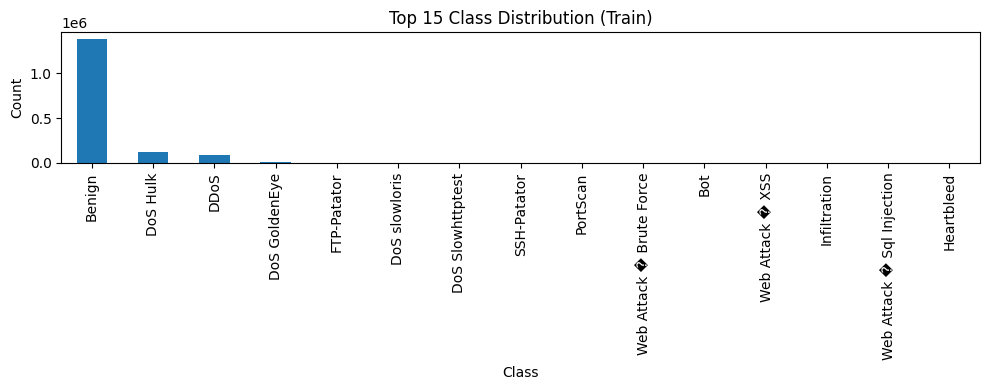

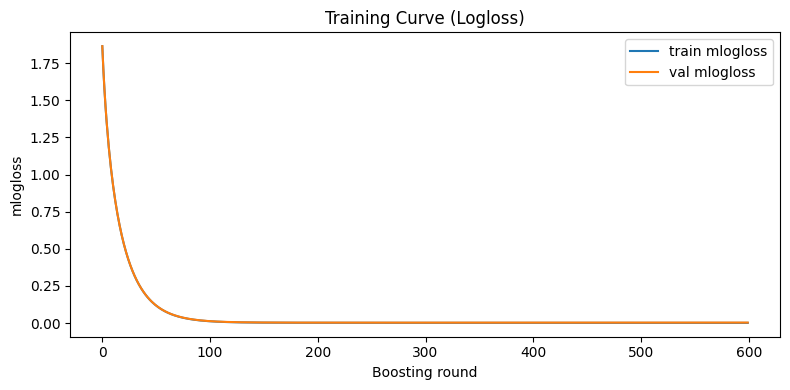

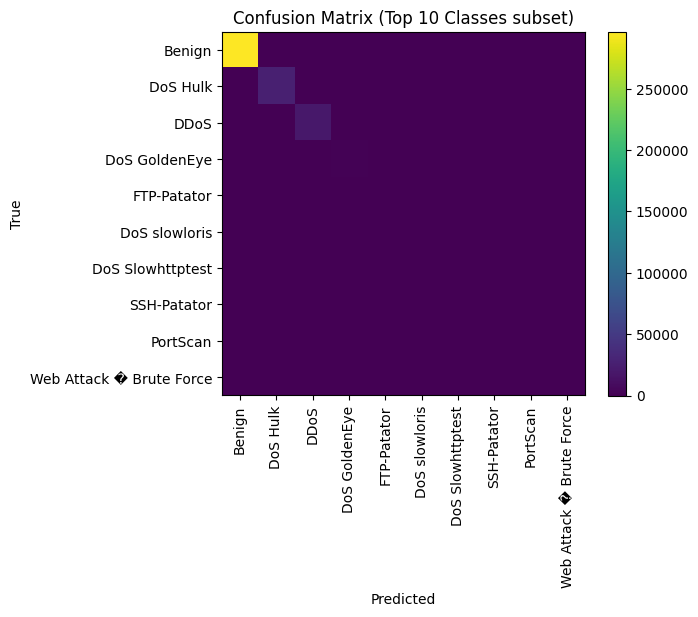

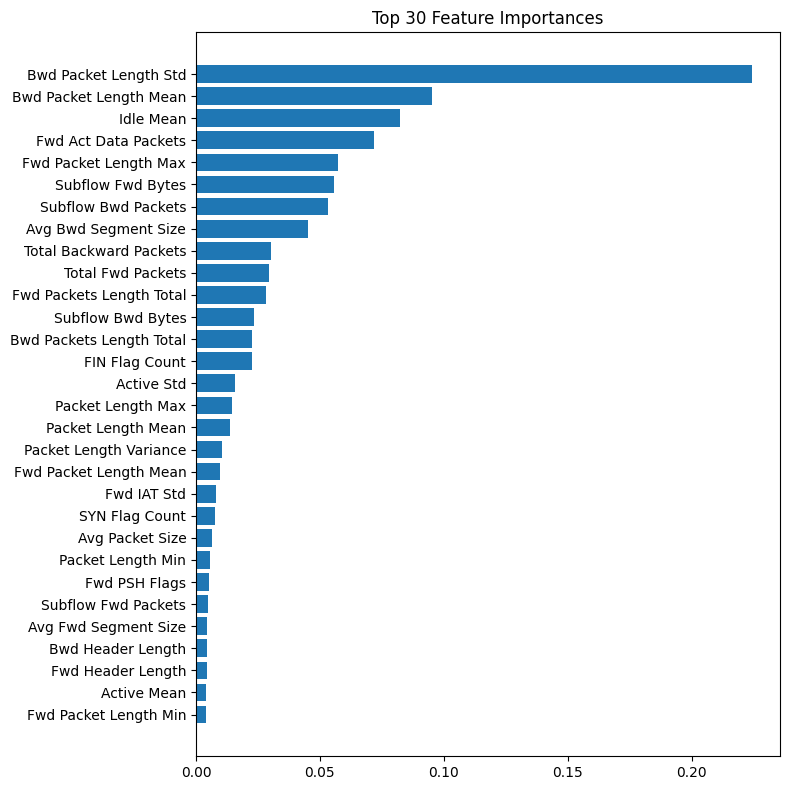

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Predictions
proba = model.predict_proba(X_test)
y_pred = np.argmax(proba, axis=1)

acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", acc)
print(classification_report(y_test, y_pred, target_names=le.classes_))

# 1) Class distribution
plt.figure(figsize=(10,4))
pd.Series(le.inverse_transform(y_train)).value_counts().head(15).plot(kind="bar")
plt.title("Top 15 Class Distribution (Train)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 2) Logloss curve
train_loss = evals["validation_0"]["mlogloss"]
val_loss   = evals["validation_1"]["mlogloss"]

plt.figure(figsize=(8,4))
plt.plot(train_loss, label="train mlogloss")
plt.plot(val_loss, label="val mlogloss")
plt.title("Training Curve (Logloss)")
plt.xlabel("Boosting round")
plt.ylabel("mlogloss")
plt.legend()
plt.tight_layout()
plt.show()

# 3) Confusion matrix (Top-K classes for readability)
K = min(10, len(le.classes_))
# pick top-K classes by support in test set
test_labels = le.inverse_transform(y_test)
top_classes = pd.Series(test_labels).value_counts().head(K).index.tolist()
top_idx = [np.where(le.classes_ == c)[0][0] for c in top_classes]

mask = np.isin(y_test, top_idx) & np.isin(y_pred, top_idx)
cm = confusion_matrix(y_test[mask], y_pred[mask], labels=top_idx)

plt.figure(figsize=(7,6))
plt.imshow(cm, interpolation="nearest")
plt.title(f"Confusion Matrix (Top {K} Classes subset)")
plt.colorbar()
plt.xticks(range(K), top_classes, rotation=90)
plt.yticks(range(K), top_classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# 4) Feature importance
importances = model.feature_importances_
top_idx = np.argsort(importances)[-30:]

plt.figure(figsize=(8,8))
plt.barh(range(len(top_idx)), importances[top_idx])
plt.yticks(range(len(top_idx)), [feature_cols[i] for i in top_idx])
plt.title("Top 30 Feature Importances")
plt.tight_layout()
plt.show()


In [ ]:
import json, joblib, os
from datetime import datetime

ARTIFACT_DIR = "/content/artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

joblib.dump(model, os.path.join(ARTIFACT_DIR, "model.joblib"))
joblib.dump(le, os.path.join(ARTIFACT_DIR, "label_encoder.joblib"))

with open(os.path.join(ARTIFACT_DIR, "feature_columns.json"), "w") as f:
    json.dump(feature_cols, f, indent=2)

metrics = {
    "timestamp": datetime.utcnow().isoformat(),
    "test_accuracy": float(acc),
    "n_classes": int(len(le.classes_)),
    "classes": le.classes_.tolist()
}
with open(os.path.join(ARTIFACT_DIR, "metrics.json"), "w") as f:
    json.dump(metrics, f, indent=2)

print("Artifacts saved in:", ARTIFACT_DIR)
print(os.listdir(ARTIFACT_DIR))


Artifacts saved in: /content/artifacts
['feature_columns.json', 'metrics.json', 'model.joblib', 'label_encoder.joblib']


/tmp/ipython-input-3304301724.py:14: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),


In [ ]:
!zip -r /content/artifacts.zip /content/artifacts


  adding: content/artifacts/ (stored 0%)
  adding: content/artifacts/feature_columns.json (deflated 75%)
  adding: content/artifacts/metrics.json (deflated 44%)
  adding: content/artifacts/model.joblib (deflated 62%)
  adding: content/artifacts/label_encoder.joblib (deflated 34%)
